# Segment-Level Analysis — Hit Noise Study

Companion notebook to `segment_level_analysis.ipynb`. Repeats the segment-level
characterisation but with two **realistic detector imperfections** layered on top of
the usual scattering and hit-resolution terms:

1. **Hit inefficiency (`drop_rate`)** — a fraction of true hits is randomly removed
   before segment building. Breaks truth tracks into sparser hit sequences, reduces
   the number of true segments, and affects *both* the shared-middle-hit triplet
   method and the all-pairs truth-segment method.
2. **Phantom / ghost hits (`ghost_rate`)** — random extra hits (with `track_id = -1`)
   are injected on random modules. Invisible to the all-pairs truth-segment method
   but directly inflates `n_false` in the triplet method (combinatorial explosion).

**Physical regime**: $\sigma_{\mathrm{scatt}} = 0.1$ mrad, $\sigma_{\mathrm{res}} = 5$ μm,
$\phi_{\max} = 0.2$ rad. Detector, $\varepsilon$ formula and kernels are identical to the
baseline notebook — only the event is post-processed by `apply_hit_noise`.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import math
import time as _time
from pathlib import Path
from types import SimpleNamespace
from numba import njit, prange

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy import get_segments_from_track

OUT_DIR = Path("outputs/segment_analysis_noise")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PAPER_DIR = OUT_DIR / "paper"
PAPER_DIR.mkdir(exist_ok=True)

print("Imports OK.")

Imports OK.


## 1. Constants & Detector Geometry

Same detector and physics as the baseline notebook. Fixed physical noise terms; we
only sweep the new hit-level noise (`drop_rate`, `ghost_rate`).

In [14]:
# ── Detector ──────────────────────────────────────────────────────
DZ_MM     = 33.0
N_MODULES = 5
Z_FIRST   = 33
HALF_X    = 40.0
HALF_Y    = 40.0

# ── Hamiltonian / reconstruction ─────────────────────────────────
GAMMA     = 3.0
DELTA     = 1.0
SCALE     = 3.0
THETA_MIN = 1.5e-5

# ── Primary vertex spread ────────────────────────────────────────
PV_SIGMA  = {"x": 0, "y": 0, "z": 1}

# ── Fixed physics terms (same as §7 of baseline) ─────────────────
PHI_MAX         = 0.2
SIGMA_SCATT_FIX = 1e-4     # 0.1 mrad
SIGMA_RES_FIX   = 0.005    # 5 µm
FIXED_EPSILON   = 0.002    # 2 mrad
EPSILON_FORMULA = float(np.sqrt(2*(SCALE*SIGMA_SCATT_FIX)**2
                                 + 12*np.arctan(SCALE*SIGMA_RES_FIX/DZ_MM)**2
                                 + 2*THETA_MIN**2))

# ── Noise sweep grids ────────────────────────────────────────────
DROP_RATES  = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
GHOST_RATES = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
TRACK_COUNTS_NOISE = [20, 100, 500]
N_REPEATS = 10

TRACK_COLORS = {20: "#2166ac", 100: "#c51b7d", 500: "#d95f02"}
TRACK_FMTS   = {20: "o-",      100: "s--",     500: "D:"}

# ── Build geometry ───────────────────────────────────────────────
z_positions = [Z_FIRST + i * DZ_MM for i in range(N_MODULES)]
geo = PlaneGeometry(
    module_id=list(range(N_MODULES)),
    lx=[HALF_X] * N_MODULES,
    ly=[HALF_Y] * N_MODULES,
    z=z_positions,
)

print(f"Detector: {N_MODULES} modules at z = {z_positions} mm")
print(f"Formula ε = {EPSILON_FORMULA*1e3:.4f} mrad   Fixed ε = {FIXED_EPSILON*1e3:.1f} mrad")
print(f"Sweep drop_rate  ∈ {DROP_RATES}")
print(f"Sweep ghost_rate ∈ {GHOST_RATES}")
print(f"Track counts     : {TRACK_COUNTS_NOISE},   repeats/point = {N_REPEATS}")

Detector: 5 modules at z = [33.0, 66.0, 99.0, 132.0, 165.0] mm
Formula ε = 1.6309 mrad   Fixed ε = 2.0 mrad
Sweep drop_rate  ∈ [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
Sweep ghost_rate ∈ [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
Track counts     : [20, 100, 500],   repeats/point = 10


## 2. Generator, Segment Kernels & Noise Model

Helpers copied verbatim from the baseline notebook, plus the new `apply_hit_noise`.

**`apply_hit_noise(event, drop_rate, ghost_rate, rng)`** returns a *new* event-like
object (duck-typed `.hits` + `.tracks`) so the original generator output is preserved.

- **Drop**: each true hit independently retained with probability $1 - p_{\text{drop}}$.
  Tracks have their `hit_ids` list rewritten to contain only surviving hits.
- **Ghost**: $\lfloor N_{\text{hits}} \cdot p_{\text{ghost}} \rfloor$ extra hits placed
  uniformly on random module faces. Each ghost has `track_id = -1`, `hit_id` in a
  non-overlapping range, and does NOT appear in any track's `hit_ids`.

In [15]:
def compute_epsilon(sigma_res, sigma_scatt, dz=DZ_MM, scale=SCALE, theta_min=THETA_MIN):
    theta_s = scale * sigma_scatt
    theta_r = np.arctan((scale * sigma_res) / dz) if dz != 0 else 0.0
    return float(np.sqrt(2 * theta_s**2 + 12 * theta_r**2 + 2 * theta_min**2))


def safe_generate(n_tracks, measurement_error=0.0, collision_noise=1e-8,
                  phi_max=0.2, theta_max=0.2, max_retries=20):
    """Generate event, retrying until every track has >= 3 hits."""
    for _ in range(max_retries):
        gen = StateEventGenerator(
            detector_geometry=geo,
            events=1, n_particles=[n_tracks],
            phi_min=-phi_max, phi_max=phi_max,
            theta_min=-theta_max, theta_max=theta_max,
            measurement_error=measurement_error,
            collision_noise=collision_noise,
        )
        gen.generate_random_primary_vertices(PV_SIGMA)
        gen.generate_particles([[{"type": "pion", "mass": 139.6, "q": 1}] * n_tracks])
        event = gen.generate_complete_events()
        if event.tracks and min(len(t.hit_ids) for t in event.tracks) >= 3:
            return event
    return event  # best effort


def apply_hit_noise(event, drop_rate=0.0, ghost_rate=0.0, rng=None):
    """Return an event-like object with hits dropped and/or ghost hits added.

    Does NOT mutate the input event. Ghost hits get `track_id = -1`.
    Tracks in the returned event have `hit_ids` filtered to surviving hits.
    """
    if rng is None:
        rng = np.random.default_rng()

    orig_hits = list(event.hits)
    n_orig = len(orig_hits)

    # ── Drop ──
    keep_mask = rng.random(n_orig) >= drop_rate if drop_rate > 0 else np.ones(n_orig, dtype=bool)
    kept_hits = [h for h, keep in zip(orig_hits, keep_mask) if keep]
    kept_ids = {h.hit_id for h in kept_hits}

    # ── Ghost hits ──
    n_ghost = int(round(n_orig * ghost_rate))
    max_orig_id = max((h.hit_id for h in orig_hits), default=-1)
    ghost_hits = []
    mod_ids = [geo.module_id[i] for i in range(len(geo.module_id))]
    z_arr   = list(geo.z)
    lx_arr  = list(geo.lx)
    ly_arr  = list(geo.ly)
    for g in range(n_ghost):
        idx = int(rng.integers(0, len(mod_ids)))
        ghost_hits.append(SimpleNamespace(
            hit_id   = max_orig_id + 1 + g,
            x        = float(rng.uniform(-lx_arr[idx], lx_arr[idx])),
            y        = float(rng.uniform(-ly_arr[idx], ly_arr[idx])),
            z        = float(z_arr[idx]),
            module_id= mod_ids[idx],
            track_id = -1,
        ))

    # ── Rebuild tracks with filtered hit_ids ──
    new_tracks = []
    for trk in event.tracks:
        new_hids = [hid for hid in trk.hit_ids if hid in kept_ids]
        new_tracks.append(SimpleNamespace(
            track_id = trk.track_id,
            hit_ids  = new_hids,
        ))

    return SimpleNamespace(hits=kept_hits + ghost_hits, tracks=new_tracks)


print("Helpers + noise model defined.")

Helpers + noise model defined.


In [16]:
# ============================================================================
# Kernel 1: shared-middle-hit triplets  (n_false ~ n^3, sensitive to GHOSTS)
# ============================================================================

@njit
def _cos_angle_inner(v1x, v1y, v1z, n1, v2x, v2y, v2z):
    n2 = math.sqrt(v2x*v2x + v2y*v2y + v2z*v2z)
    if n1 == 0.0 or n2 == 0.0:
        return 1.0
    c = (v1x*v2x + v1y*v2y + v1z*v2z) / (n1 * n2)
    return max(-1.0, min(1.0, c))


@njit
def _count_one_mid(i, px, py, pz, mx, my, mz, nx_, ny, nz,
                   p_tid, m_tid, n_tid, cos_eps):
    loc_nt = loc_nf = loc_ta = loc_fa = 0
    mid_tid = m_tid[i]
    for j in range(len(px)):
        v1x = mx[i] - px[j]; v1y = my[i] - py[j]; v1z = mz[i] - pz[j]
        n1 = math.sqrt(v1x*v1x + v1y*v1y + v1z*v1z)
        seg_in_true = (p_tid[j] >= 0) and (p_tid[j] == mid_tid)
        for k in range(len(nx_)):
            v2x = nx_[k] - mx[i]; v2y = ny[k] - my[i]; v2z = nz[k] - mz[i]
            ca = _cos_angle_inner(v1x, v1y, v1z, n1, v2x, v2y, v2z)
            is_true = seg_in_true and (mid_tid == n_tid[k])
            if is_true:
                loc_nt += 1
                if ca >= cos_eps: loc_ta += 1
            else:
                loc_nf += 1
                if ca >= cos_eps: loc_fa += 1
    return loc_nt, loc_nf, loc_ta, loc_fa


@njit(parallel=True)
def _segment_counts_module(px, py, pz, mx, my, mz, nx_, ny, nz,
                           p_tid, m_tid, n_tid, cos_eps):
    n_m = len(mx)
    nt_arr = np.zeros(n_m, dtype=np.int64)
    nf_arr = np.zeros(n_m, dtype=np.int64)
    ta_arr = np.zeros(n_m, dtype=np.int64)
    fa_arr = np.zeros(n_m, dtype=np.int64)
    for i in prange(n_m):
        _nt, _nf, _ta, _fa = _count_one_mid(
            i, px, py, pz, mx, my, mz, nx_, ny, nz,
            p_tid, m_tid, n_tid, cos_eps)
        nt_arr[i] = _nt; nf_arr[i] = _nf
        ta_arr[i] = _ta; fa_arr[i] = _fa
    return nt_arr.sum(), nf_arr.sum(), ta_arr.sum(), fa_arr.sum()


def fast_segment_metrics(event, epsilon):
    cos_eps = math.cos(epsilon)
    hits_by_mod = {}
    for h in event.hits:
        hits_by_mod.setdefault(h.module_id, []).append(h)
    sorted_mods = sorted(hits_by_mod.keys())

    def _arr(hlist):
        x = np.array([h.x for h in hlist], dtype=np.float64)
        y = np.array([h.y for h in hlist], dtype=np.float64)
        z = np.array([h.z for h in hlist], dtype=np.float64)
        tid = np.array([h.track_id if h.track_id is not None else -1
                        for h in hlist], dtype=np.int64)
        return x, y, z, tid

    moda = {m: _arr(hits_by_mod[m]) for m in sorted_mods}
    n_true = n_false = ta_sum = fa_sum = 0
    for mi in range(1, len(sorted_mods) - 1):
        p = moda[sorted_mods[mi-1]]; m = moda[sorted_mods[mi]]; n = moda[sorted_mods[mi+1]]
        nt, nf, ta, fa = _segment_counts_module(p[0], p[1], p[2], m[0], m[1], m[2],
                                                n[0], n[1], n[2], p[3], m[3], n[3], cos_eps)
        n_true += nt; n_false += nf; ta_sum += ta; fa_sum += fa
    tot = ta_sum + fa_sum
    return {
        "n_true": int(n_true), "n_false": int(n_false),
        "true_accepted": int(ta_sum), "false_accepted": int(fa_sum),
        "segment_efficiency": ta_sum / n_true if n_true > 0 else 0.0,
        "segment_false_rate": fa_sum / tot if tot > 0 else 0.0,
    }


# ============================================================================
# Kernel 2: all-pairs of truth segments  (n_false ~ n^2, blind to GHOSTS)
# ============================================================================

@njit(parallel=True)
def _pairwise_seg_counts(vx, vy, vz, norms, tids, cos_eps):
    n = len(vx)
    nt_arr = np.zeros(n, dtype=np.int64)
    nf_arr = np.zeros(n, dtype=np.int64)
    ta_arr = np.zeros(n, dtype=np.int64)
    fa_arr = np.zeros(n, dtype=np.int64)
    for i in prange(n):
        ni = norms[i]
        if ni == 0.0: continue
        uix = vx[i]/ni; uiy = vy[i]/ni; uiz = vz[i]/ni
        tid_i = tids[i]
        for j in range(i+1, n):
            nj = norms[j]
            if nj == 0.0: continue
            cos_a = uix*(vx[j]/nj) + uiy*(vy[j]/nj) + uiz*(vz[j]/nj)
            if cos_a > 1.0: cos_a = 1.0
            elif cos_a < -1.0: cos_a = -1.0
            is_true = (tid_i >= 0) and (tid_i == tids[j])
            if is_true:
                nt_arr[i] += 1
                if cos_a >= cos_eps: ta_arr[i] += 1
            else:
                nf_arr[i] += 1
                if cos_a >= cos_eps: fa_arr[i] += 1
    return nt_arr.sum(), nf_arr.sum(), ta_arr.sum(), fa_arr.sum()


def fast_pairwise_metrics(event, epsilon):
    cos_eps = math.cos(epsilon)
    hit_lookup = {h.hit_id: h for h in event.hits}
    svx, svy, svz, snorm, stid = [], [], [], [], []
    for trk in event.tracks:
        hids = trk.hit_ids
        tid = trk.track_id if trk.track_id is not None else -1
        for k in range(len(hids) - 1):
            if hids[k] not in hit_lookup or hids[k+1] not in hit_lookup:
                continue
            hf, ht = hit_lookup[hids[k]], hit_lookup[hids[k+1]]
            dx = ht.x - hf.x; dy = ht.y - hf.y; dz = ht.z - hf.z
            svx.append(dx); svy.append(dy); svz.append(dz)
            snorm.append(math.sqrt(dx*dx + dy*dy + dz*dz))
            stid.append(tid)
    if not svx:
        return {"n_true": 0, "n_false": 0, "true_accepted": 0,
                "false_accepted": 0, "segment_efficiency": 0.0, "segment_false_rate": 0.0}
    vx = np.array(svx, dtype=np.float64); vy = np.array(svy, dtype=np.float64)
    vz = np.array(svz, dtype=np.float64); nrm = np.array(snorm, dtype=np.float64)
    tid = np.array(stid, dtype=np.int64)
    nt, nf, ta, fa = _pairwise_seg_counts(vx, vy, vz, nrm, tid, cos_eps)
    nt, nf, ta, fa = int(nt), int(nf), int(ta), int(fa)
    tot = ta + fa
    return {"n_true": nt, "n_false": nf, "true_accepted": ta, "false_accepted": fa,
            "segment_efficiency": ta/nt if nt > 0 else 0.0,
            "segment_false_rate": fa/tot if tot > 0 else 0.0}


# ── JIT warmup & sanity ──
_evt = safe_generate(10, measurement_error=SIGMA_RES_FIX,
                     collision_noise=SIGMA_SCATT_FIX,
                     phi_max=PHI_MAX, theta_max=PHI_MAX)
_ = fast_segment_metrics(_evt, 0.002)
_ = fast_pairwise_metrics(_evt, 0.002)
print("Kernels JIT-compiled.")

Kernels JIT-compiled.


## 3. Sanity Check — a clean vs noisy event

Run `apply_hit_noise` on a single 20-track event with moderate noise to confirm
that hit counts, truth-segment counts, and metric direction-of-change make sense.

In [17]:
_rng = np.random.default_rng(42)
_clean = safe_generate(20, measurement_error=SIGMA_RES_FIX,
                       collision_noise=SIGMA_SCATT_FIX,
                       phi_max=PHI_MAX, theta_max=PHI_MAX)
print(f"Clean event: {len(_clean.hits)} hits, {len(_clean.tracks)} tracks")

for d, g in [(0.0, 0.0), (0.1, 0.0), (0.0, 0.2), (0.1, 0.2)]:
    ev = apply_hit_noise(_clean, drop_rate=d, ghost_rate=g, rng=_rng)
    n_ghost = sum(1 for h in ev.hits if h.track_id == -1)
    n_real = len(ev.hits) - n_ghost
    mt = fast_segment_metrics(ev, EPSILON_FORMULA)
    mp = fast_pairwise_metrics(ev, FIXED_EPSILON)
    print(f"  drop={d:.2f} ghost={g:.2f} | real={n_real:4d} ghost={n_ghost:4d} "
          f"| triplet nT={mt['n_true']:4d} nF={mt['n_false']:6d} eff={mt['segment_efficiency']*100:5.1f}% "
          f"| pairs nT={mp['n_true']:4d} nF={mp['n_false']:6d} eff={mp['segment_efficiency']*100:5.1f}%")

Clean event: 100 hits, 20 tracks
  drop=0.00 ghost=0.00 | real= 100 ghost=   0 | triplet nT=  60 nF= 23940 eff=100.0% | pairs nT= 120 nF=  3040 eff=100.0%
  drop=0.10 ghost=0.00 | real=  91 ghost=   0 | triplet nT=  43 nF= 17722 eff=100.0% | pairs nT=  93 nF=  2392 eff=100.0%
  drop=0.00 ghost=0.20 | real= 100 ghost=  20 | triplet nT=  60 nF= 41965 eff=100.0% | pairs nT= 120 nF=  3040 eff=100.0%
  drop=0.10 ghost=0.20 | real=  94 ghost=  20 | triplet nT=  49 nF= 32753 eff=100.0% | pairs nT= 102 nF=  2599 eff=100.0%


## 4. Drop-Rate Sweep (ghost_rate = 0)

Sweep hit inefficiency from 0 to 30% at three track multiplicities. Measures both
the triplet method (§4a) and the all-pairs truth method (§4b) — both should show
`segment_efficiency` fall and `n_true` drop as hits vanish.

In [18]:
# ============================================================================
# §4. Drop-Rate Sweep — data collection
# ============================================================================
_cache = CACHE_DIR / "df_drop_sweep.csv"
if _cache.exists():
    df_drop = pd.read_csv(_cache)
    print(f"Loaded drop sweep from cache: {len(df_drop)} rows")
else:
    rows = []
    t_start = _time.time()
    for n_trk in TRACK_COUNTS_NOISE:
        t0 = _time.time()
        for di, drop in enumerate(DROP_RATES):
            for rep in range(N_REPEATS):
                seed = rep + n_trk * 100 + di * 10000 + 1_100_000
                np.random.seed(seed)
                rng = np.random.default_rng(seed)
                clean = safe_generate(n_trk, measurement_error=SIGMA_RES_FIX,
                                      collision_noise=SIGMA_SCATT_FIX,
                                      phi_max=PHI_MAX, theta_max=PHI_MAX)
                ev = apply_hit_noise(clean, drop_rate=drop, ghost_rate=0.0, rng=rng)
                m_trip = fast_segment_metrics(ev, EPSILON_FORMULA)
                m_pair = fast_pairwise_metrics(ev, FIXED_EPSILON)
                rows.append({
                    "n_tracks": n_trk, "drop_rate": drop, "ghost_rate": 0.0,
                    "repeat": rep,
                    **{f"trip_{k}": v for k, v in m_trip.items()},
                    **{f"pair_{k}": v for k, v in m_pair.items()},
                })
        print(f"  n_tracks={n_trk:4d}  done  ({_time.time()-t0:.1f}s)")
    df_drop = pd.DataFrame(rows)
    df_drop.to_csv(_cache, index=False)
    print(f"\n{len(df_drop)} rows saved ({_time.time()-t_start:.0f}s)")

Loaded drop sweep from cache: 240 rows


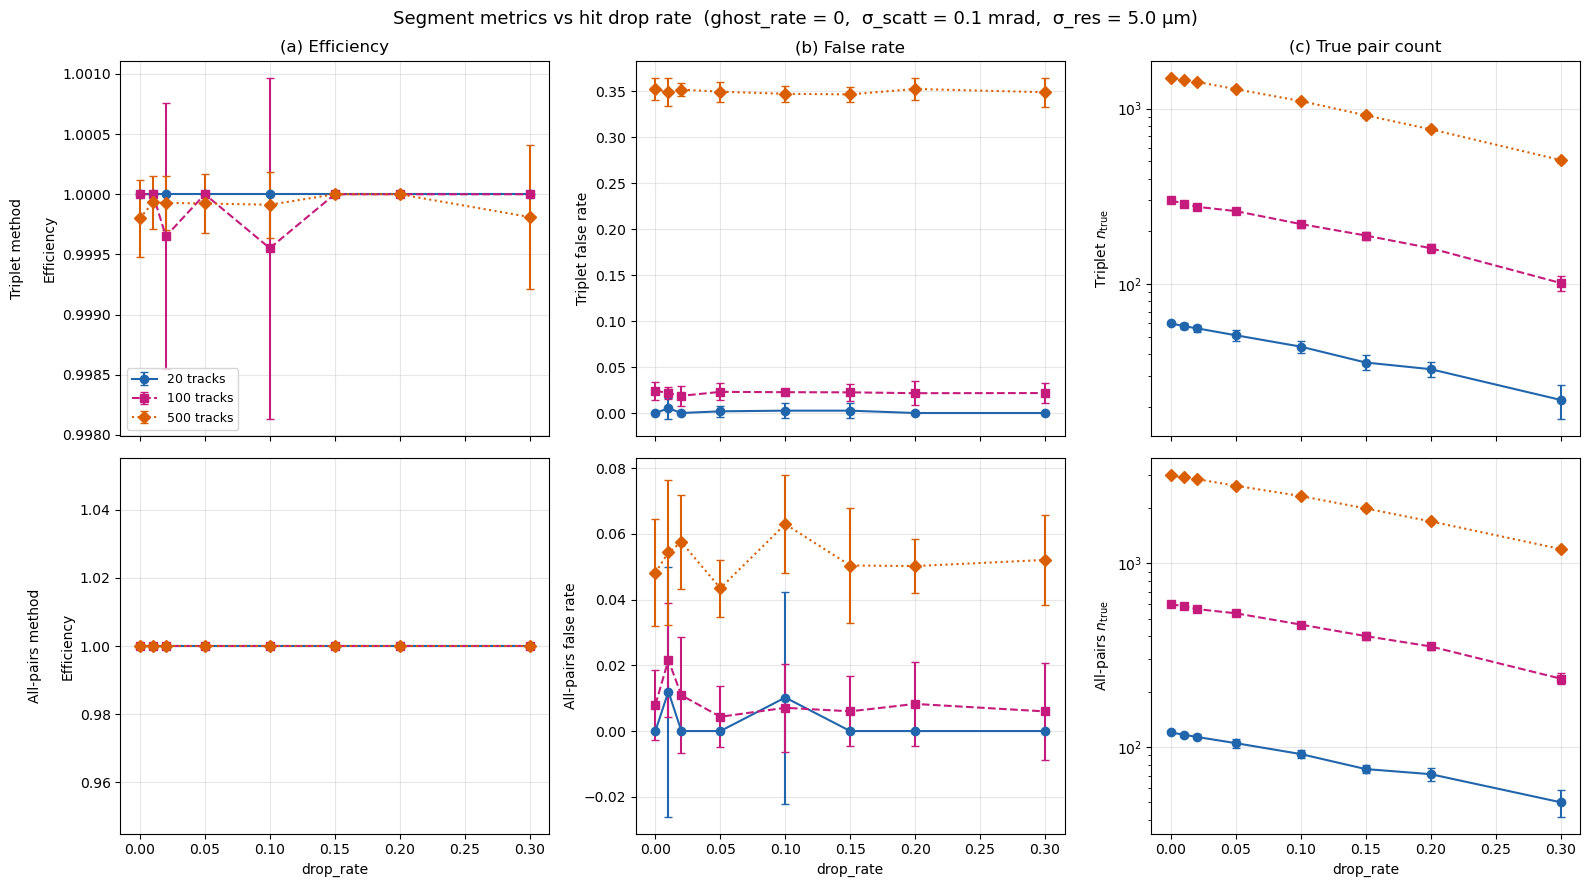

In [19]:
# ============================================================================
# §4. Drop-Rate Sweep — plot (triplet + pairwise side-by-side)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
fig.suptitle(f"Segment metrics vs hit drop rate  (ghost_rate = 0,  "
             f"σ_scatt = {SIGMA_SCATT_FIX*1e3:.1f} mrad,  σ_res = {SIGMA_RES_FIX*1e3:.1f} μm)",
             fontsize=13)

metrics = [
    ("trip_segment_efficiency", "Triplet eff.",          0),
    ("trip_segment_false_rate", "Triplet false rate",    1),
    ("trip_n_true",             "Triplet $n_{\\mathrm{true}}$",  2),
    ("pair_segment_efficiency", "All-pairs eff.",        0),
    ("pair_segment_false_rate", "All-pairs false rate",  1),
    ("pair_n_true",             "All-pairs $n_{\\mathrm{true}}$", 2),
]

for idx, (col, ylabel, axcol) in enumerate(metrics):
    ax = axes[idx // 3, axcol]
    for n_trk in TRACK_COUNTS_NOISE:
        g = df_drop[df_drop.n_tracks == n_trk].groupby("drop_rate")[col]
        m, s = g.mean(), g.std()
        ax.errorbar(m.index, m.values, yerr=s.values,
                    fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                    capsize=3, ms=6, label=f"{n_trk} tracks")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=9, loc="lower left")

axes[0, 0].set_title("(a) Efficiency")
axes[0, 1].set_title("(b) False rate")
axes[0, 2].set_title("(c) True pair count")
axes[0, 2].set_yscale("log")
axes[1, 2].set_yscale("log")
axes[0, 0].set_ylabel("Triplet method\n\nEfficiency")
axes[1, 0].set_ylabel("All-pairs method\n\nEfficiency")
for ax in axes[1]:
    ax.set_xlabel("drop_rate")

fig.tight_layout()
fig.savefig(PAPER_DIR / "fig_drop_sweep.png", dpi=200, bbox_inches="tight")
fig.savefig(PAPER_DIR / "fig_drop_sweep.pdf", bbox_inches="tight")
plt.show()

## 5. Ghost-Rate Sweep (drop_rate = 0)

Sweep phantom-hit rate from 0 to 50% of total hits. **Only the triplet method sees
the ghosts** (the all-pairs method iterates truth-track segments). Expect the
triplet `n_false` and false rate to explode while `n_true` stays constant.

In [20]:
# ============================================================================
# §5. Ghost-Rate Sweep — data collection
# ============================================================================
_cache = CACHE_DIR / "df_ghost_sweep.csv"
if _cache.exists():
    df_ghost = pd.read_csv(_cache)
    print(f"Loaded ghost sweep from cache: {len(df_ghost)} rows")
else:
    rows = []
    t_start = _time.time()
    for n_trk in TRACK_COUNTS_NOISE:
        t0 = _time.time()
        for gi, ghost in enumerate(GHOST_RATES):
            for rep in range(N_REPEATS):
                seed = rep + n_trk * 100 + gi * 10000 + 1_200_000
                np.random.seed(seed)
                rng = np.random.default_rng(seed)
                clean = safe_generate(n_trk, measurement_error=SIGMA_RES_FIX,
                                      collision_noise=SIGMA_SCATT_FIX,
                                      phi_max=PHI_MAX, theta_max=PHI_MAX)
                ev = apply_hit_noise(clean, drop_rate=0.0, ghost_rate=ghost, rng=rng)
                m_trip = fast_segment_metrics(ev, EPSILON_FORMULA)
                m_pair = fast_pairwise_metrics(ev, FIXED_EPSILON)
                rows.append({
                    "n_tracks": n_trk, "drop_rate": 0.0, "ghost_rate": ghost,
                    "repeat": rep,
                    **{f"trip_{k}": v for k, v in m_trip.items()},
                    **{f"pair_{k}": v for k, v in m_pair.items()},
                })
        print(f"  n_tracks={n_trk:4d}  done  ({_time.time()-t0:.1f}s)")
    df_ghost = pd.DataFrame(rows)
    df_ghost.to_csv(_cache, index=False)
    print(f"\n{len(df_ghost)} rows saved ({_time.time()-t_start:.0f}s)")

Loaded ghost sweep from cache: 210 rows


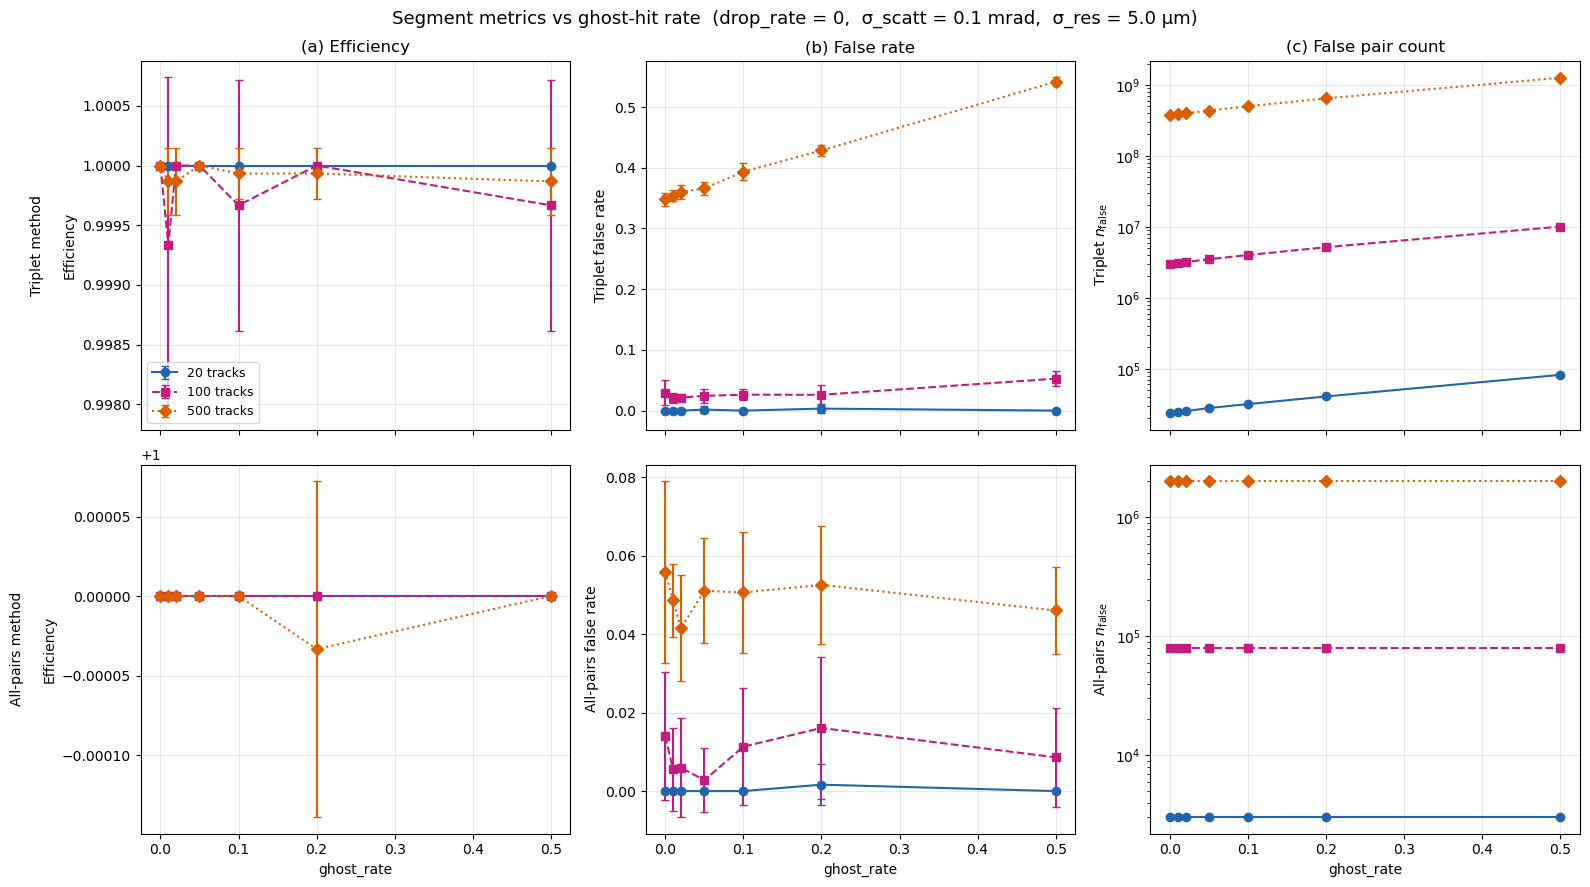

In [21]:
# ============================================================================
# §5. Ghost-Rate Sweep — plot
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
fig.suptitle(f"Segment metrics vs ghost-hit rate  (drop_rate = 0,  "
             f"σ_scatt = {SIGMA_SCATT_FIX*1e3:.1f} mrad,  σ_res = {SIGMA_RES_FIX*1e3:.1f} μm)",
             fontsize=13)

metrics = [
    ("trip_segment_efficiency", "Triplet eff.",           0),
    ("trip_segment_false_rate", "Triplet false rate",     1),
    ("trip_n_false",            "Triplet $n_{\\mathrm{false}}$", 2),
    ("pair_segment_efficiency", "All-pairs eff.",         0),
    ("pair_segment_false_rate", "All-pairs false rate",   1),
    ("pair_n_false",            "All-pairs $n_{\\mathrm{false}}$", 2),
]

for idx, (col, ylabel, axcol) in enumerate(metrics):
    ax = axes[idx // 3, axcol]
    for n_trk in TRACK_COUNTS_NOISE:
        g = df_ghost[df_ghost.n_tracks == n_trk].groupby("ghost_rate")[col]
        m, s = g.mean(), g.std()
        ax.errorbar(m.index, m.values, yerr=s.values,
                    fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                    capsize=3, ms=6, label=f"{n_trk} tracks")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=9, loc="lower left")

axes[0, 0].set_title("(a) Efficiency")
axes[0, 1].set_title("(b) False rate")
axes[0, 2].set_title("(c) False pair count")
axes[0, 2].set_yscale("log")
axes[1, 2].set_yscale("log")
axes[0, 0].set_ylabel("Triplet method\n\nEfficiency")
axes[1, 0].set_ylabel("All-pairs method\n\nEfficiency")
for ax in axes[1]:
    ax.set_xlabel("ghost_rate")

fig.tight_layout()
fig.savefig(PAPER_DIR / "fig_ghost_sweep.png", dpi=200, bbox_inches="tight")
fig.savefig(PAPER_DIR / "fig_ghost_sweep.pdf", bbox_inches="tight")
plt.show()

## 6. Combined Drop × Ghost Scan

Full 2-D grid of (drop_rate, ghost_rate) at a single track multiplicity.
Produces heatmaps of triplet efficiency and triplet false rate — the two primary
quantities the original paper's $\varepsilon$ cut relies on. Use `n_tracks = 100`
(representative LHCb event).

In [22]:
# ============================================================================
# §6. Combined Drop × Ghost Scan — data collection
# ============================================================================
N_TRACKS_2D     = 100
DROP_GRID_2D    = [0.0, 0.02, 0.05, 0.10, 0.20]
GHOST_GRID_2D   = [0.0, 0.02, 0.05, 0.10, 0.20, 0.50]
N_REPEATS_2D    = 10

_cache = CACHE_DIR / "df_drop_ghost_2d.csv"
if _cache.exists():
    df_2d = pd.read_csv(_cache)
    print(f"Loaded 2D scan from cache: {len(df_2d)} rows")
else:
    rows = []
    t_start = _time.time()
    for di, drop in enumerate(DROP_GRID_2D):
        for gi, ghost in enumerate(GHOST_GRID_2D):
            for rep in range(N_REPEATS_2D):
                seed = rep + di * 1000 + gi * 100000 + 1_300_000
                np.random.seed(seed)
                rng = np.random.default_rng(seed)
                clean = safe_generate(N_TRACKS_2D, measurement_error=SIGMA_RES_FIX,
                                      collision_noise=SIGMA_SCATT_FIX,
                                      phi_max=PHI_MAX, theta_max=PHI_MAX)
                ev = apply_hit_noise(clean, drop_rate=drop, ghost_rate=ghost, rng=rng)
                m_trip = fast_segment_metrics(ev, EPSILON_FORMULA)
                rows.append({"drop_rate": drop, "ghost_rate": ghost, "repeat": rep,
                             **{f"trip_{k}": v for k, v in m_trip.items()}})
            print(f"  drop={drop:.2f} ghost={ghost:.2f}  done  ({_time.time()-t_start:.0f}s)")
    df_2d = pd.DataFrame(rows)
    df_2d.to_csv(_cache, index=False)
    print(f"\n{len(df_2d)} rows saved ({_time.time()-t_start:.0f}s)")

Loaded 2D scan from cache: 300 rows


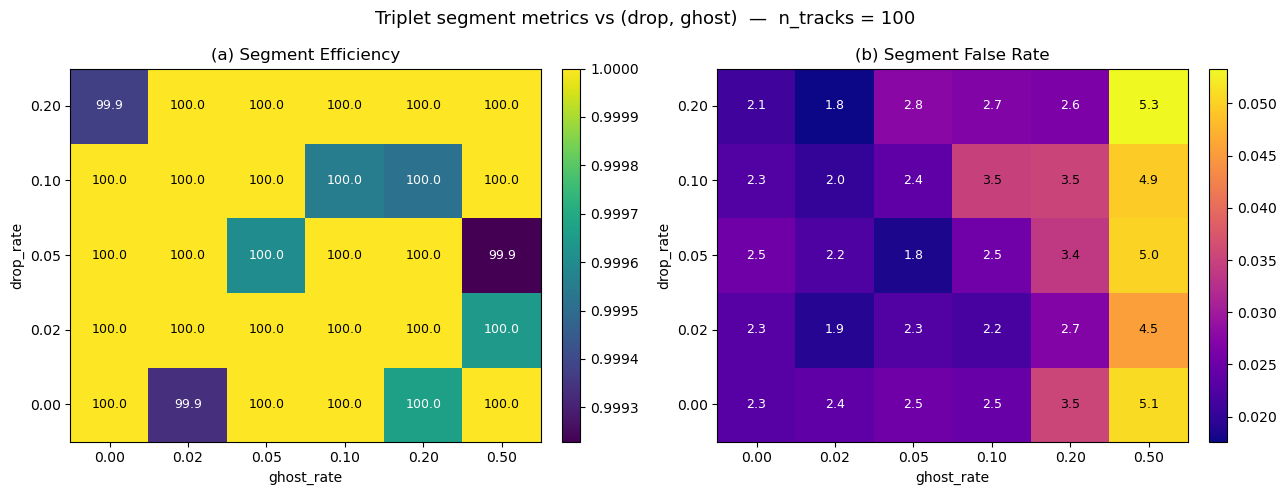

In [23]:
# ============================================================================
# §6. Combined Drop × Ghost Scan — heatmaps
# ============================================================================
eff_grid = (df_2d.groupby(["drop_rate", "ghost_rate"])["trip_segment_efficiency"].mean()
              .unstack())
fr_grid  = (df_2d.groupby(["drop_rate", "ghost_rate"])["trip_segment_false_rate"].mean()
              .unstack())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Triplet segment metrics vs (drop, ghost)  —  n_tracks = {N_TRACKS_2D}",
             fontsize=13)

for ax, grid, title, cmap in [
    (axes[0], eff_grid, "(a) Segment Efficiency", "viridis"),
    (axes[1], fr_grid,  "(b) Segment False Rate", "plasma")]:
    im = ax.imshow(grid.values, origin="lower", aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([f"{g:.2f}" for g in grid.columns])
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{d:.2f}" for d in grid.index])
    ax.set_xlabel("ghost_rate")
    ax.set_ylabel("drop_rate")
    ax.set_title(title)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid.values[i, j]
            ax.text(j, i, f"{v*100:.1f}", ha="center", va="center",
                    color="white" if v < grid.values.mean() else "black", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(PAPER_DIR / "fig_drop_ghost_heatmap.png", dpi=200, bbox_inches="tight")
fig.savefig(PAPER_DIR / "fig_drop_ghost_heatmap.pdf", bbox_inches="tight")
plt.show()

## 7. Summary

Aggregate tables for each sweep and export raw CSVs alongside the baseline
analysis outputs.

In [24]:
summary_drop = (df_drop.groupby(["n_tracks", "drop_rate"])
                        [["trip_segment_efficiency", "trip_segment_false_rate",
                          "pair_segment_efficiency", "pair_segment_false_rate"]]
                        .agg(["mean", "std"]).round(4))
print("="*80); print("DROP-RATE SWEEP SUMMARY"); print("="*80)
display(summary_drop)

summary_ghost = (df_ghost.groupby(["n_tracks", "ghost_rate"])
                          [["trip_segment_efficiency", "trip_segment_false_rate",
                            "trip_n_false",
                            "pair_segment_efficiency", "pair_segment_false_rate"]]
                          .agg(["mean", "std"]).round(4))
print("\n" + "="*80); print("GHOST-RATE SWEEP SUMMARY"); print("="*80)
display(summary_ghost)

summary_2d = (df_2d.groupby(["drop_rate", "ghost_rate"])
                    [["trip_segment_efficiency", "trip_segment_false_rate"]]
                    .agg(["mean", "std"]).round(4))
print("\n" + "="*80); print(f"COMBINED DROP × GHOST (n_tracks = {N_TRACKS_2D})"); print("="*80)
display(summary_2d)

# Export raw CSVs
df_drop.to_csv(OUT_DIR / "drop_sweep.csv", index=False)
df_ghost.to_csv(OUT_DIR / "ghost_sweep.csv", index=False)
df_2d.to_csv(OUT_DIR / "drop_ghost_2d.csv", index=False)
print(f"\nSaved CSVs to {OUT_DIR}/")

DROP-RATE SWEEP SUMMARY


trip_segment_efficiency         trip_segment_false_rate  \
                                      mean     std                    mean   
n_tracks drop_rate                                                           
20       0.00                       1.0000  0.0000                  0.0000   
         0.01                       1.0000  0.0000                  0.0051   
         0.02                       1.0000  0.0000                  0.0000   
         0.05                       1.0000  0.0000                  0.0019   
         0.10                       1.0000  0.0000                  0.0026   
         0.15                       1.0000  0.0000                  0.0026   
         0.20                       1.0000  0.0000                  0.0000   
         0.30                       1.0000  0.0000                  0.0000   
100      0.00                       1.0000  0.0000                  0.0243   
         0.01                       1.0000  0.0000                  0.0217   
         0.02                       0.9997  0.0011                  0.0187   
         0.05                       1.0000  0.0000                  0.0230   
         0.10                       0.9996  0.0014                  0.0227   
         0.15                       1.0000  0.0000                  0.0225   
         0.20                       1.0000  0.0000                  0.0216   
         0.30                       1.0000  0.0000                  0.0217   
500      0.00                       0.9998  0.0003                  0.3527   
         0.01                       0.9999  0.0002                  0.3493   
         0.02                       0.9999  0.0002                  0.3520   
         0.05                       0.9999  0.0002                  0.3498   
         0.10                       0.9999  0.0003                  0.3474   
         0.15                       1.0000  0.0000                  0.3468   
         0.20                       1.0000  0.0000                  0.3527   
         0.30                       0.9998  0.0006                  0.3492   

                           pair_segment_efficiency       \
                       std                    mean  std   
n_tracks drop_rate                                        
20       0.00       0.0000                     1.0  0.0   
         0.01       0.0113                     1.0  0.0   
         0.02       0.0000                     1.0  0.0   
         0.05       0.0059                     1.0  0.0   
         0.10       0.0081                     1.0  0.0   
         0.15       0.0081                     1.0  0.0   
         0.20       0.0000                     1.0  0.0   
         0.30       0.0000                     1.0  0.0   
100      0.00       0.0097                     1.0  0.0   
         0.01       0.0068                     1.0  0.0   
         0.02       0.0109                     1.0  0.0   
         0.05       0.0092                     1.0  0.0   
         0.10       0.0027                     1.0  0.0   
         0.15       0.0093                     1.0  0.0   
         0.20       0.0128                     1.0  0.0   
         0.30       0.0113                     1.0  0.0   
500      0.00       0.0116                     1.0  0.0   
         0.01       0.0156                     1.0  0.0   
         0.02       0.0074                     1.0  0.0   
         0.05       0.0107                     1.0  0.0   
         0.10       0.0090                     1.0  0.0   
         0.15       0.0082                     1.0  0.0   
         0.20       0.0122                     1.0  0.0   
         0.30       0.0158                     1.0  0.0   

                   pair_segment_false_rate          
                                      mean     std  
n_tracks drop_rate                                  
20       0.00                       0.0000  0.0000  
         0.01                       0.0120  0.0380  
         0.02                       0.0000  0.0000  



GHOST-RATE SWEEP SUMMARY


trip_segment_efficiency         trip_segment_false_rate  \
                                       mean     std                    mean   
n_tracks ghost_rate                                                           
20       0.00                        1.0000  0.0000                  0.0000   
         0.01                        1.0000  0.0000                  0.0000   
         0.02                        1.0000  0.0000                  0.0000   
         0.05                        1.0000  0.0000                  0.0016   
         0.10                        1.0000  0.0000                  0.0000   
         0.20                        1.0000  0.0000                  0.0033   
         0.50                        1.0000  0.0000                  0.0000   
100      0.00                        1.0000  0.0000                  0.0296   
         0.01                        0.9993  0.0014                  0.0208   
         0.02                        1.0000  0.0000                  0.0215   
         0.05                        1.0000  0.0000                  0.0243   
         0.10                        0.9997  0.0011                  0.0262   
         0.20                        1.0000  0.0000                  0.0260   
         0.50                        0.9997  0.0011                  0.0526   
500      0.00                        1.0000  0.0000                  0.3484   
         0.01                        0.9999  0.0003                  0.3535   
         0.02                        0.9999  0.0003                  0.3603   
         0.05                        1.0000  0.0000                  0.3660   
         0.10                        0.9999  0.0002                  0.3936   
         0.20                        0.9999  0.0002                  0.4285   
         0.50                        0.9999  0.0003                  0.5419   

                             trip_n_false                \
                        std          mean           std   
n_tracks ghost_rate                                       
20       0.00        0.0000  2.394000e+04  0.000000e+00   
         0.01        0.0000  2.470000e+04  3.977716e+02   
         0.02        0.0000  2.527400e+04  3.371844e+02   
         0.05        0.0052  2.795840e+04  6.515230e+02   
         0.10        0.0000  3.175890e+04  1.070392e+03   
         0.20        0.0069  4.071420e+04  1.630191e+03   
         0.50        0.0000  8.205480e+04  4.322275e+03   
100      0.00        0.0210  2.999700e+06  0.000000e+00   
         0.01        0.0084  3.088372e+06  1.918165e+04   
         0.02        0.0064  3.186986e+06  1.965380e+04   
         0.05        0.0119  3.495960e+06  3.009548e+04   
         0.10        0.0087  4.006128e+06  5.419208e+04   
         0.20        0.0167  5.159066e+06  9.090634e+04   
         0.50        0.0119  1.009194e+07  3.221658e+05   
500      0.00        0.0107  3.749985e+08  0.000000e+00   
         0.01        0.0091  3.861282e+08  8.459310e+05   
         0.02        0.0113  3.971120e+08  1.602772e+06   
         0.05        0.0101  4.338663e+08  1.669911e+06   
         0.10        0.0143  5.004281e+08  4.784230e+06   
         0.20        0.0083  6.453405e+08  5.071713e+06   
         0.50        0.0070  1.261781e+09  1.406903e+07   

                    pair_segment_efficiency         pair_segment_false_rate  \
                                       mean     std                    mean   
n_tracks ghost_rate                                                           
20       0.00                           1.0  0.0000                  0.0000   
         0.01                           1.0  0.0000                  0.0000   
         0.02                           1.0  0.0000                  0.0000   
         0.05                           1.0  0.0000                  0.0000   
         0.10                           1.0  0.0000                  0.0000   
         0.20                           1.0  0.0000                  0.001


COMBINED DROP × GHOST (n_tracks = 100)


trip_segment_efficiency         trip_segment_false_rate  \
                                        mean     std                    mean   
drop_rate ghost_rate                                                           
0.00      0.00                        1.0000  0.0000                  0.0231   
          0.02                        0.9993  0.0014                  0.0237   
          0.05                        1.0000  0.0000                  0.0253   
          0.10                        1.0000  0.0000                  0.0246   
          0.20                        0.9997  0.0011                  0.0354   
          0.50                        1.0000  0.0000                  0.0509   
0.02      0.00                        1.0000  0.0000                  0.0231   
          0.02                        1.0000  0.0000                  0.0191   
          0.05                        1.0000  0.0000                  0.0227   
          0.10                        1.0000  0.0000                  0.0218   
          0.20                        1.0000  0.0000                  0.0271   
          0.50                        0.9996  0.0011                  0.0455   
0.05      0.00                        1.0000  0.0000                  0.0252   
          0.02                        1.0000  0.0000                  0.0223   
          0.05                        0.9996  0.0013                  0.0183   
          0.10                        1.0000  0.0000                  0.0254   
          0.20                        1.0000  0.0000                  0.0339   
          0.50                        0.9992  0.0016                  0.0503   
0.10      0.00                        1.0000  0.0000                  0.0228   
          0.02                        1.0000  0.0000                  0.0201   
          0.05                        1.0000  0.0000                  0.0238   
          0.10                        0.9996  0.0014                  0.0349   
          0.20                        0.9995  0.0015                  0.0353   
          0.50                        1.0000  0.0000                  0.0495   
0.20      0.00                        0.9994  0.0020                  0.0212   
          0.02                        1.0000  0.0000                  0.0176   
          0.05                        1.0000  0.0000                  0.0277   
          0.10                        1.0000  0.0000                  0.0269   
          0.20                        1.0000  0.0000                  0.0265   
          0.50                        1.0000  0.0000                  0.0533   

                              
                         std  
drop_rate ghost_rate          
0.00      0.00        0.0071  
          0.02        0.0107  
          0.05        0.0089  
          0.10        0.0098  
          0.20        0.0174  
          0.50        0.0177  
0.02      0.00        0.0096  
          0.02        0.0050  
          0.05        0.0061  
          0.10        0.0062  
          0.20        0.0070  
          0.50        0.0121  
0.05      0.00        0.0150  
          0.02        0.0088  
          0.05        0.0093  
          0.10        0.0106  
          0.20        0.0195  
          0.50        0.0143  
0.10      0.00        0.0105  
          0.02        0.0078  
          0.05        0.0117  
          0.10        0.0181  
          0.20        0.0103  
          0.50        0.0099  
0.20      0.00        0.0171  
          0.02        0.0110  
          0.05        0.0134  
          0.10        0.0175  
          0.20        0.0119  
          0.50        0.0250


Saved CSVs to outputs/segment_analysis_noise/
